# 👗 Fashion Trend Forecaster

## Predicting Fashion Product Trends Using Machine Learning

### Project Overview

Fashion retailers launch hundreds of new products every season. Predicting which products are likely to become popular before they are released is a challenging task.

This project aims to build a Machine Learning model that predicts the trend potential of a fashion product based on its characteristics.

Since real retail company data cannot be shared, a realistic synthetic dataset has been generated. 

## 🎯 Business Problem

Fashion companies invest significant resources in designing, manufacturing and distributing new collections.

Incorrect demand forecasting may lead to:

- Overstock
- Excessive discounts
- Lost profit
- Customer dissatisfaction

The objective of this project is to estimate a product's trend potential before it reaches customers.

## 📊 Project Workflow

1. Import Libraries
2. Generate Synthetic Dataset
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Explainable AI
8. Streamlit Dashboard
9. Conclusion

In [1358]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Random seed for reproducibility
np.random.seed(42)

# Plot style
sns.set_style("whitegrid")

# 2. Generate Synthetic Fashion Dataset

In [1359]:
def generate_fashion_dataset():

    # Date range
    dates = pd.date_range(
        start="2024-01-01",
        end="2026-06-30",
        freq="D"
    )

    # Product categories
    categories = [
        "Dress",
        "T-Shirt",
        "Sweater",
        "Jacket",
        "Pants"
    ]

    # Empty list for dataset
    data = []

    # Generate synthetic data
    for date in dates:
        for category in categories:

            # Base sales
            sales = np.random.randint(50, 200)

            # Seasonal effects
            if category in ["Dress", "T-Shirt"] and date.month in [5, 6, 7, 8]:
                sales += np.random.randint(80, 180)

            if category in ["Sweater", "Jacket"] and date.month in [11, 12, 1, 2]:
                sales += np.random.randint(100, 220)

            # Price
            price = np.random.randint(150, 1500)

            # Discount
            discount = np.random.choice([0, 10, 20, 30, 40])

            # Social media trend score
            trend_score = np.random.uniform(1, 10)

            # Stock
            stock = np.random.randint(100, 1000)

            # Rating
            rating = np.random.uniform(3.5, 5.0)

            # Marketing budget
            marketing = np.random.randint(5000, 100000)

            data.append({
                "Date": date,
                "Category": category,
                "Sales": sales,
                "Price": price,
                "Discount": discount,
                "TrendScore": trend_score,
                "Stock": stock,
                "Rating": rating,
                "MarketingBudget": marketing
            })

    df = pd.DataFrame(data)

    return df

In [1360]:
df = generate_fashion_dataset()

df.head()

,Date,Category,Sales,Price,Discount,TrendScore,Stock,Rating,MarketingBudget
0,2024-01-01,Dress,152,1010,20,8.017219,120,3.734028,87386
1,2024-01-01,T-Shirt,124,237,40,6.410035,763,4.476333,69820
2,2024-01-01,Sweater,238,955,10,2.636425,376,4.426222,90305
3,2024-01-01,Jacket,278,1006,0,5.722972,610,3.709241,7747
4,2024-01-01,Pants,64,339,20,4.442158,343,4.388622,16394


In [1361]:
df.shape

(4560, 9)

# 3. Exploratory Data Analysis (EDA)

In [1362]:
# Dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             4560 non-null   datetime64[us]
 1   Category         4560 non-null   str           
 2   Sales            4560 non-null   int64         
 3   Price            4560 non-null   int64         
 4   Discount         4560 non-null   int64         
 5   TrendScore       4560 non-null   float64       
 6   Stock            4560 non-null   int64         
 7   Rating           4560 non-null   float64       
 8   MarketingBudget  4560 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(1)
memory usage: 320.8 KB


In [1363]:
# Statistical summary
df.describe()

,Date,Sales,Price,Discount,TrendScore,Stock,Rating,MarketingBudget
count,4560,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000,4560.000000
mean,2025-03-31 12:00:00,163.210088,839.665351,19.969298,5.479330,551.980702,4.250617,52574.991886
min,2024-01-01 00:00:00,50.000000,150.000000,0.000000,1.000276,100.000000,3.500356,5014.000000
25%,2024-08-15 18:00:00,100.000000,499.750000,10.000000,3.252255,328.000000,3.882075,28159.500000
50%,2025-03-31 12:00:00,152.000000,846.000000,20.000000,5.454324,550.500000,4.255357,53155.500000
75%,2025-11-14 06:00:00,198.000000,1186.000000,30.000000,7.712617,777.000000,4.615725,76755.250000
max,2026-06-30 00:00:00,407.000000,1499.000000,40.000000,9.997970,999.000000,4.999337,99977.000000
std,NaN,79.825620,391.402811,14.257954,2.598813,260.841835,0.429285,27698.937595


In [1364]:
# Missing values
df.isnull().sum()

Date               0
Category           0
Sales              0
Price              0
Discount           0
TrendScore         0
Stock              0
Rating             0
MarketingBudget    0
dtype: int64

In [1365]:
# First 10 rows
df.head(10)

,Date,Category,Sales,Price,Discount,TrendScore,Stock,Rating,MarketingBudget
0,2024-01-01,Dress,152,1010,20,8.017219,120,3.734028,87386
1,2024-01-01,T-Shirt,124,237,40,6.410035,763,4.476333,69820
2,2024-01-01,Sweater,238,955,10,2.636425,376,4.426222,90305
3,2024-01-01,Jacket,278,1006,0,5.722972,610,3.709241,7747
4,2024-01-01,Pants,64,339,20,4.442158,343,4.388622,16394
5,2024-01-02,Dress,100,796,40,5.054493,373,4.923328,78969
6,2024-01-02,T-Shirt,58,714,10,7.158097,466,4.524895,53555
7,2024-01-02,Sweater,203,184,0,3.329020,971,4.633042,71557
8,2024-01-02,Jacket,336,1279,30,2.663690,802,4.763427,76211
9,2024-01-02,Pants,63,965,30,1.407046,395,4.766801,29300


## Category Distribution

Let's see how many products belong to each category.

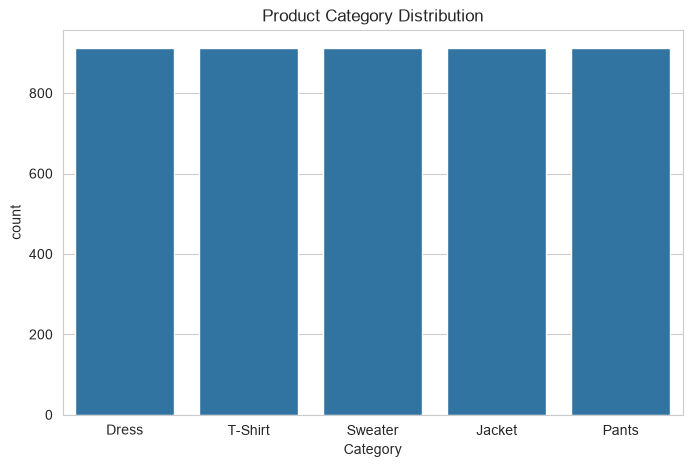

In [1366]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Product Category Distribution")
plt.show()

## Average Sales by Category

This chart shows which product category has the highest average sales.

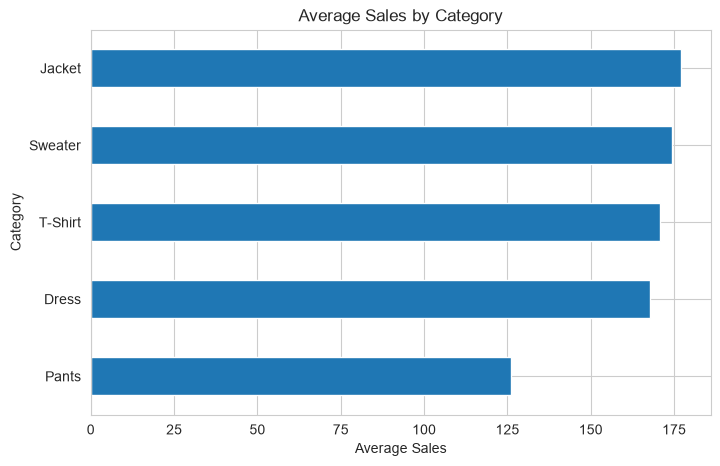

In [1367]:
plt.figure(figsize=(8,5))

df.groupby("Category")["Sales"].mean().sort_values().plot(
    kind="barh"
)

plt.title("Average Sales by Category")
plt.xlabel("Average Sales")
plt.show()

## Sales Distribution

Understanding the overall distribution of sales values.

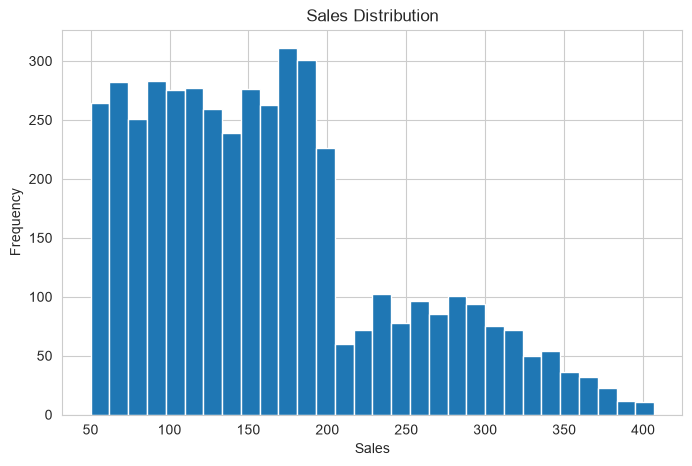

In [1368]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## Price Distribution

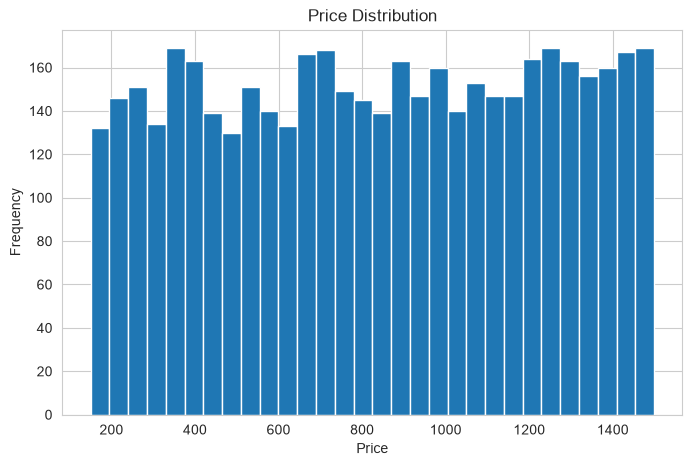

In [1369]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## Correlation Matrix

Analyzing relationships between numerical variables.

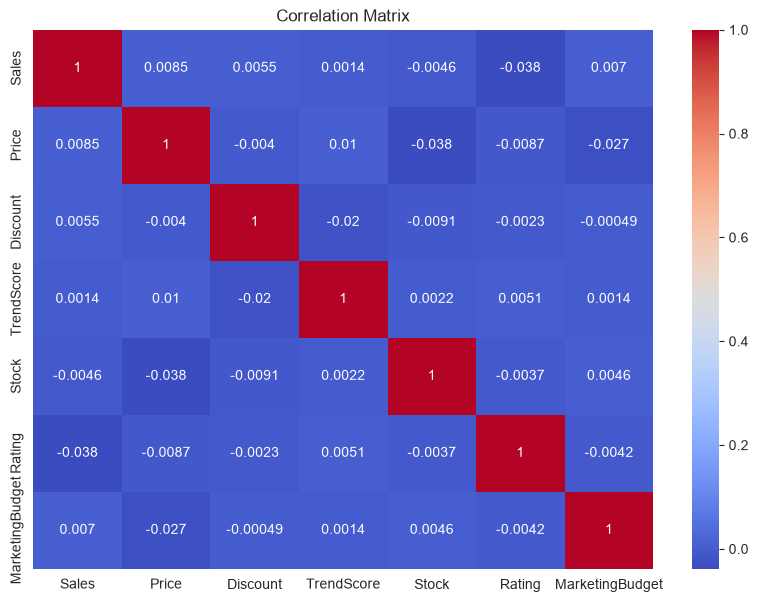

In [1370]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# 4. Feature Engineering

Creating new features that can improve model performance.

In [1371]:
# Month

df["Month"] = df["Date"].dt.month

# Quarter

df["Quarter"] = df["Date"].dt.quarter

# Day of Week

df["DayOfWeek"] = df["Date"].dt.dayofweek

In [1372]:
df.head()

,Date,Category,Sales,Price,Discount,TrendScore,Stock,Rating,MarketingBudget,Month,Quarter,DayOfWeek
0,2024-01-01,Dress,152,1010,20,8.017219,120,3.734028,87386,1,1,0
1,2024-01-01,T-Shirt,124,237,40,6.410035,763,4.476333,69820,1,1,0
2,2024-01-01,Sweater,238,955,10,2.636425,376,4.426222,90305,1,1,0
3,2024-01-01,Jacket,278,1006,0,5.722972,610,3.709241,7747,1,1,0
4,2024-01-01,Pants,64,339,20,4.442158,343,4.388622,16394,1,1,0


# Trend değişkenini oluştur

In [1373]:


df["Trend"] = (df["Sales"] > df["Sales"].quantile(0.75)).astype(int)

In [1374]:
df[["Sales", "Trend"]].head(20)

,Sales,Trend
0,152,0
1,124,0
2,238,1
3,278,1
4,64,0
5,100,0
6,58,0
7,203,1
8,336,1
9,63,0


In [1375]:
df["Trend"].value_counts()

Trend
0    3450
1    1110
Name: count, dtype: int64

In [1376]:
df["Trend"].value_counts(normalize=True) * 100

Trend
0    75.657895
1    24.342105
Name: proportion, dtype: float64

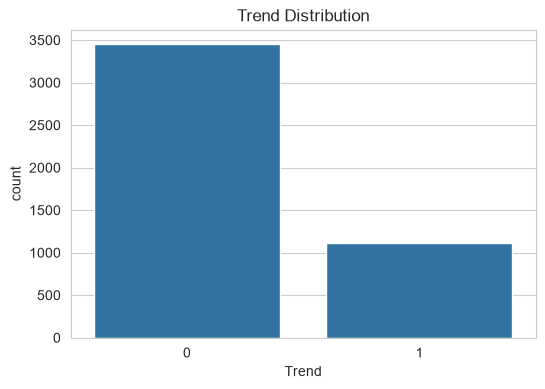

In [1377]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Trend"
)

plt.title("Trend Distribution")
plt.show()

In [1378]:
df.head()

,Date,Category,Sales,Price,Discount,TrendScore,Stock,Rating,MarketingBudget,Month,Quarter,DayOfWeek,Trend
0,2024-01-01,Dress,152,1010,20,8.017219,120,3.734028,87386,1,1,0,0
1,2024-01-01,T-Shirt,124,237,40,6.410035,763,4.476333,69820,1,1,0,0
2,2024-01-01,Sweater,238,955,10,2.636425,376,4.426222,90305,1,1,0,1
3,2024-01-01,Jacket,278,1006,0,5.722972,610,3.709241,7747,1,1,0,1
4,2024-01-01,Pants,64,339,20,4.442158,343,4.388622,16394,1,1,0,0


# Data Preprocessing

In [1379]:
X = df.drop(
    columns=[
        "Date",
        "Sales",
        "Trend"
    ]
)

y = df["Trend"]

In [1380]:
X = pd.get_dummies(
    X,
    columns=["Category"],
    drop_first=True
)

In [1381]:
X.head()

,Price,Discount,TrendScore,Stock,Rating,MarketingBudget,Month,Quarter,DayOfWeek,Category_Jacket,Category_Pants,Category_Sweater,Category_T-Shirt
0,1010,20,8.017219,120,3.734028,87386,1,1,0,False,False,False,False
1,237,40,6.410035,763,4.476333,69820,1,1,0,False,False,False,True
2,955,10,2.636425,376,4.426222,90305,1,1,0,False,False,True,False
3,1006,0,5.722972,610,3.709241,7747,1,1,0,True,False,False,False
4,339,20,4.442158,343,4.388622,16394,1,1,0,False,True,False,False


In [1382]:
print(X.shape)
print(y.shape)

(4560, 13)
(4560,)


In [1383]:
from sklearn.model_selection import train_test_split

In [1384]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [1385]:
print(X_train.shape)
print(X_test.shape)

(3648, 13)
(912, 13)


In [1386]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Model oluştur

In [1387]:
log_model = LogisticRegression(max_iter=1000)

# Eğit

In [1388]:
log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Tahmin yap

In [1389]:
y_pred = log_model.predict(X_test)

# Accuracy

In [1390]:
accuracy_score(y_test, y_pred)

0.756578947368421

# Classification Report

In [1391]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       690
           1       0.00      0.00      0.00       222

    accuracy                           0.76       912
   macro avg       0.38      0.50      0.43       912
weighted avg       0.57      0.76      0.65       912



# Confusion Matrix

In [1392]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[690,   0],
       [222,   0]])

# Heatmap

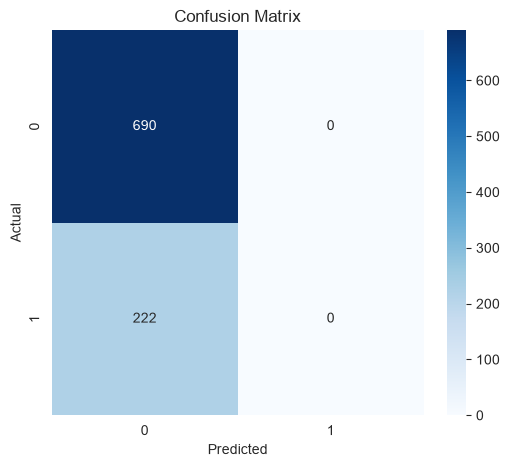

In [1393]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#  Random Forest

In [1394]:
from sklearn.ensemble import RandomForestClassifier

In [1395]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [1396]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [1397]:
rf_pred = rf.predict(X_test)

In [1398]:
accuracy_score(y_test, rf_pred)

0.9517543859649122

In [1399]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       690
           1       0.86      0.96      0.91       222

    accuracy                           0.95       912
   macro avg       0.92      0.95      0.94       912
weighted avg       0.96      0.95      0.95       912



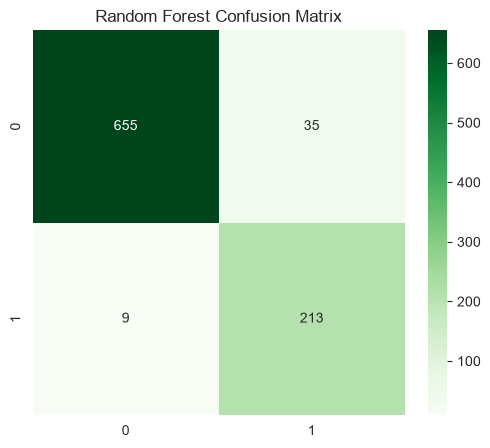

In [1400]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

# Feature Importance   

In [1401]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

In [1402]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
6,Month,0.276269
11,Category_Sweater,0.105541
9,Category_Jacket,0.103769
7,Quarter,0.079506
10,Category_Pants,0.070498
4,Rating,0.060090
0,Price,0.056580
5,MarketingBudget,0.056050
3,Stock,0.054857
2,TrendScore,0.053958


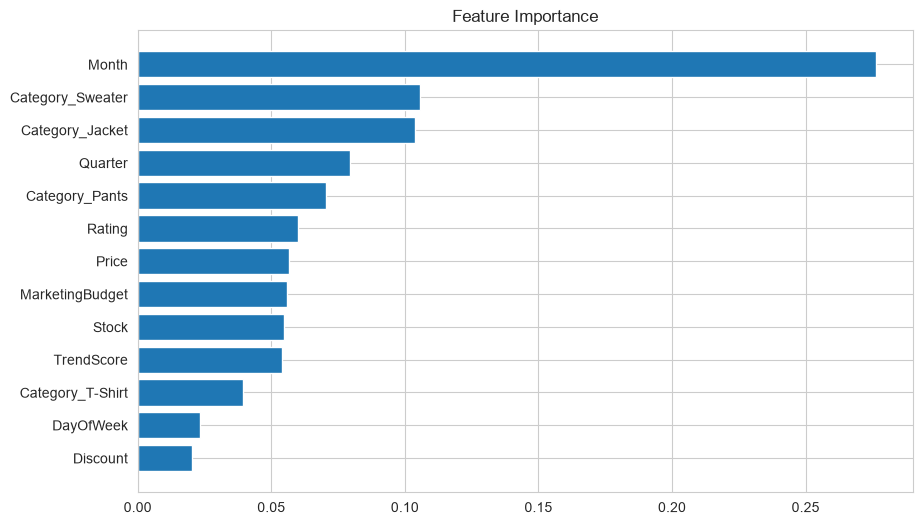

In [1403]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

# Veriyi Kaydetme

In [1404]:
df.to_csv("../data/fashion_trend_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


# Modeli Kaydetme

In [1405]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


# Feature Listesini Kaydetme

In [1406]:
joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [1407]:
import joblib

In [1408]:
joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [1409]:
joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [1410]:
df.to_csv("../data/fashion_trend_dataset.csv", index=False)

# 8. Save Model

In [1411]:
import joblib

In [1412]:
joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [1413]:
joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [1414]:
df.to_csv("../data/fashion_trend_dataset.csv", index=False)

In [1415]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [1416]:
X.columns.tolist()

['Price',
 'Discount',
 'TrendScore',
 'Stock',
 'Rating',
 'MarketingBudget',
 'Month',
 'Quarter',
 'DayOfWeek',
 'Category_Jacket',
 'Category_Pants',
 'Category_Sweater',
 'Category_T-Shirt']

In [1417]:
import joblib

feature_names = joblib.load("../models/features.pkl")

feature_names

['Price',
 'Discount',
 'TrendScore',
 'Stock',
 'Rating',
 'MarketingBudget',
 'Month',
 'Quarter',
 'DayOfWeek',
 'Category_Jacket',
 'Category_Pants',
 'Category_Sweater',
 'Category_T-Shirt']

In [1418]:
df.columns

Index(['Date', 'Category', 'Sales', 'Price', 'Discount', 'TrendScore', 'Stock',
       'Rating', 'MarketingBudget', 'Month', 'Quarter', 'DayOfWeek', 'Trend'],
      dtype='str')

In [1419]:
import joblib

model = joblib.load("../models/random_forest.pkl")

In [1420]:
importance = model.feature_importances_

joblib.dump(importance, "../models/importance.pkl")

['../models/importance.pkl']